Debt-service pressure and climate vulnerability: auditable reconstruction

This companion reads the saved verified outputs. It is not the estimation engine; the complete models can be rerun with ppml_pipeline.py and the locked inputs. All values are reconstructed from current official public-source vintages. Original-draft coefficients are not used as inputs or targets.

Summary

The main recipient-clustered PPML interaction is positive. Joint common-support inference supports a difference from mitigation; the non-climate contrast remains imprecise. Conditional debt-service associations differ across observed vulnerability levels. These are observational allocation associations. Instrument support is uneven and provider concentration matters. Later-period and debt-stock sensitivities are less precise. Targeted post-baseline checks and all-provider omissions retain a positive main interaction; their post-baseline status is explicit. See the saved model diagnostics and bundled VALIDATION.md before using any result.

In [1]:
from pathlib import Path
import json, platform, importlib.metadata as md
import pandas as pd
import numpy as np
from IPython.display import display, Image
ROOT=Path.cwd()
if not (ROOT/'outputs').exists(): ROOT=ROOT/'analysis'
OUT=ROOT/'outputs'; MODELS=OUT/'models'
pd.set_option('display.max_columns',12)
pd.set_option('display.float_format',lambda x:f'{x:.4f}')
print('Python',platform.python_version(),'PyFixest',md.version('pyfixest'))

Python 3.12.14 PyFixest 0.60.0


Sources, transformations and design

Official OECD CRS v20260803; World Bank debt and macroeconomic series; FERDI PVCCI October 2018 workbook. Commitments are constant 2024 US$ millions. Real GDP per capita is constant 2015 US$. Debt service is public/publicly guaranteed plus IMF debt service divided by exports of goods, services and primary income. Lags match the previous calendar year exactly. Static PVCCI is standardized once across unique eligible baseline recipients, using the population SD.

The strict reporting universe contains observed country-government provider–recipient–year–sector cells only when every eligible activity has two valid climate markers. Both principal climate markers may overlap; principal-only and both-zero non-climate outcomes are neither mutually exclusive nor exhaustive. Unreported cells are not created as zeros.

In [2]:
print((OUT/'pvcci_standardization.json').read_text())
display(pd.read_csv(OUT/'paper/table4_sample_flow.csv'))

{
  "mean": 53.46656348693887,
  "sd_population_ddof0": 6.454156228861506,
  "n_unique_recipients": 109,
  "baseline_start_year": 2015,
  "baseline_end_year": 2024,
  "timing": "before all outcome-specific pruning"
}


,stage,cells,recipients,providers,years
0,classified_source_cells,112940,152,33,"2010,2011,2012,2013,2014,2015,2016,2017,2018,2..."
1,analysis_period,107668,148,33,"2011,2012,2013,2014,2015,2016,2017,2018,2019,2..."
2,complete_lag_covariates,91890,111,33,"2011,2012,2013,2014,2015,2016,2017,2018,2019,2..."
3,primary_2015_2024_before_separation,68945,109,33,2015–2024


Descriptives at their correct observation level

In [3]:
display(pd.read_csv(OUT/'descriptive_recipient_year_covariates.csv').iloc[:,:8])
display(pd.read_csv(OUT/'descriptive_recipient_vulnerability.csv').iloc[:,:8])

,Unnamed: 0,grain,count,mean,std,min,1%,10%
0,debt_ratio_lag,recipient_year_covariates,1057.0000,8.3222,7.0778,0.0081,0.3218,1.6942
1,gdppc_lag,recipient_year_covariates,1057.0000,3803.9736,3116.5927,254.4026,427.7822,722.2235
2,population_lag,recipient_year_covariates,1057.0000,56587341.6017,191793111.7298,101323.0000,105548.0800,617500.8000


,Unnamed: 0,grain,count,mean,std,min,1%,10%
0,pvcci,recipient_vulnerability,109.0000,53.4666,6.4840,39.8449,40.6942,45.6303
1,vuln_z,recipient_vulnerability,109.0000,-0.0000,1.0046,-2.1105,-1.9789,-1.2141


Model and inference

PPML includes provider–recipient, provider–year and three-digit sector fixed effects; lagged debt service divided by ten, its interaction with standardized PVCCI, and logged lagged GDP per capita and population. Recipient CRV1 covariance is primary, with normal-reference intervals; t-reference inference is a sensitivity. Raw two-way covariance is a diagnostic, and non-PSD matrices are not repaired or promoted to confirmatory inference. Structural singleton/all-zero-FE pruning is followed by package FE and iterated-rectifier separation checks. Numerical recovery and failed attempts are documented in NUMERICAL_NOTES.md.

In [4]:
display(pd.read_csv(OUT/'paper/table1_main_models.csv'))
meta=json.loads((MODELS/'adaptation_total/diagnostics.json').read_text())
print('Convergence:',meta['convergence'],'retained N:',meta['n'])
print('Two-way PSD:',meta['twoway']['psd'],'eigenvalues:',meta['twoway']['eigenvalues'])

Convergence: True retained N: 53565
Two-way PSD: False eigenvalues: [-0.004362613514694216, 0.009022981472679397, 0.8880305441042377, 5.167374340988718]


,outcome,beta_debt10,se_debt10,p_debt10,beta_interaction,se_interaction,...,recipients,providers,zero_share,usd2024_billion,provider_effective_volume_n,two_way_psd
0,Adaptation: total,-0.2526,0.1869,0.1765,0.5315,0.1655,...,108,29,0.9110,20.9613,3.9872,False
1,Mitigation: total,-0.2449,0.1368,0.0734,-0.1441,0.1100,...,108,29,0.9009,61.3181,3.5683,False
2,Non-climate: total,-0.1525,0.1209,0.2070,0.1250,0.1197,...,109,31,0.1348,257.6861,2.8715,True
3,Adaptation: grants,-0.0961,0.1361,0.4801,0.3038,0.1213,...,108,29,0.9124,8.1294,6.9467,True
4,Adaptation: loans,-0.2441,0.3270,0.4554,0.6421,0.2620,...,43,7,0.9175,12.8168,2.0919,False
5,Mitigation: grants,-0.0220,0.1061,0.8361,0.1130,0.0884,...,108,29,0.9051,9.9139,4.0750,False
6,Mitigation: loans,-0.3225,0.2120,0.1281,-0.1866,0.1516,...,64,6,0.9154,51.3209,3.0596,False


Conditional debt-service slopes

For vulnerability z, the log conditional-mean association for a ten-percentage-point debt-service rise is beta_D + z beta_DZ. Its variance includes the covariance cross-term. Exponential intervals describe the exact proportional association. Curves use observed recipient support and pointwise 95% intervals.

,point,vuln_z,pvcci_raw,log_mean_slope,se,ci95_low,ci95_high,percent_change_10pp,percent_ci_low,percent_ci_high
0,minus_one_SD,-1.0000,47.0124,-0.7841,0.3009,-1.3739,-0.1944,-54.3486,-74.6874,-17.6674
1,baseline_mean,0.0000,53.4666,-0.2526,0.1869,-0.6190,0.1137,-22.3254,-46.1498,12.0394
2,plus_one_SD,1.0000,59.9207,0.2789,0.1847,-0.0832,0.6410,32.1613,-7.9874,89.8285
3,retained_country_p10,-1.2181,45.6048,-0.9000,0.3316,-1.5499,-0.2502,-59.3450,-78.7735,-22.1339
4,retained_country_p25,-0.7124,48.8685,-0.6313,0.2625,-1.1459,-0.1167,-46.8093,-68.2052,-11.0153
5,retained_country_p50,-0.1649,52.4025,-0.3403,0.2008,-0.7339,0.0533,-28.8418,-51.9945,5.4772
6,retained_country_p75,0.7974,58.6133,0.1712,0.1728,-0.1675,0.5099,18.6715,-15.4254,66.5150
7,retained_country_p90,1.3211,61.9930,0.4495,0.2133,0.0314,0.8676,56.7530,3.1941,138.1095


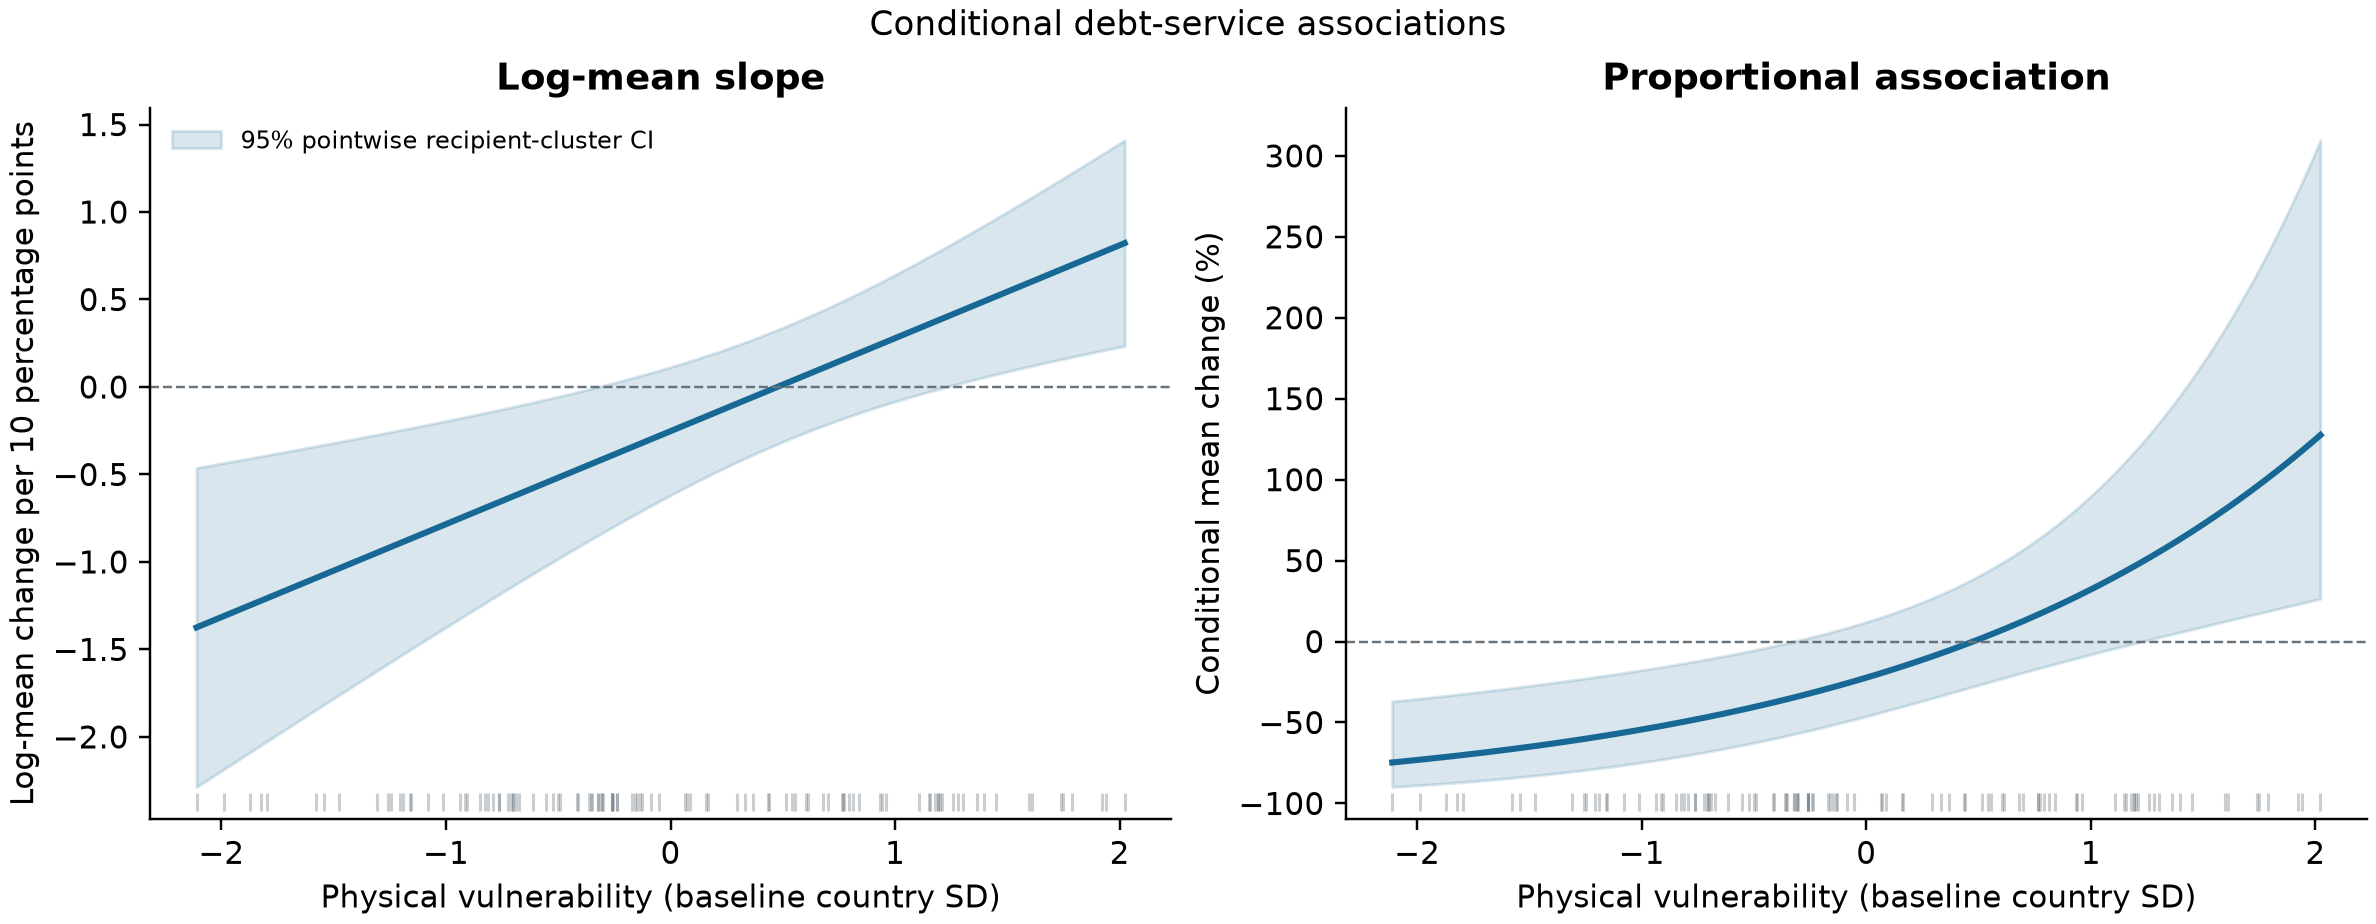

In [5]:
display(pd.read_csv(MODELS/'adaptation_total/conditional_debt_effect_landmarks.csv'))
display(Image(filename=str(OUT/'paper/figure1_conditional_debt_association.png')))

Formal cross-purpose comparisons

Each contrast stacks purpose outcomes on iteratively matched finite-identification support, with purpose-specific slopes and all purpose-specific nuisance effects. Original recipient IDs retain cross-purpose dependence. Holm adjustment applies to the two planned total-purpose tests.

In [6]:
display(pd.read_csv(MODELS/'planned_total_contrasts.csv')[['contrast','common_cells','recipients','providers','estimate','se','ci95_low','ci95_high','p_normal','p_holm_planned_total_family']])

,contrast,common_cells,recipients,providers,estimate,se,ci95_low,ci95_high,p_normal,p_holm_planned_total_family
0,adaptation_total minus nonclimate_total,53523,108,29,0.3935,0.2188,-0.0353,0.8223,0.0721,0.0721
1,adaptation_total minus mitigation_total,45666,106,27,0.7151,0.1394,0.4418,0.9884,0.0000,0.0000


Prespecified sensitivities

In [7]:
display(pd.read_csv(OUT/'paper/table3_prespecified_sensitivities.csv')[['model','n','recipients','providers','estimate','se','ci95_low','ci95_high','p_normal']])

,model,n,recipients,providers,estimate,se,ci95_low,ci95_high,p_normal
0,adaptation_post2018,30086,107,28,0.2584,0.1615,-0.0580,0.5749,0.1095
1,adaptation_exclusive,49650,108,27,0.4128,0.1385,0.1413,0.6843,0.0029
2,adaptation_principal_significant,63095,109,30,0.2152,0.0883,0.0420,0.3883,0.0149
3,adaptation_ppg_only,53565,108,29,0.6350,0.1870,0.2685,1.0014,0.0007
4,adaptation_debt_stock,53251,108,29,0.1606,0.0952,-0.0261,0.3472,0.0917
5,adaptation_pvcci2,53565,108,29,0.5351,0.1619,0.2177,0.8524,0.0010
6,adaptation_pvcci3,53565,108,29,0.5347,0.1604,0.2204,0.8490,0.0009
7,adaptation_valid_records,62069,108,29,0.5323,0.1673,0.2045,0.8602,0.0015
8,adaptation_including_EU,55952,108,30,0.3319,0.1507,0.0365,0.6272,0.0276


Reporting coverage and concentrated loan support

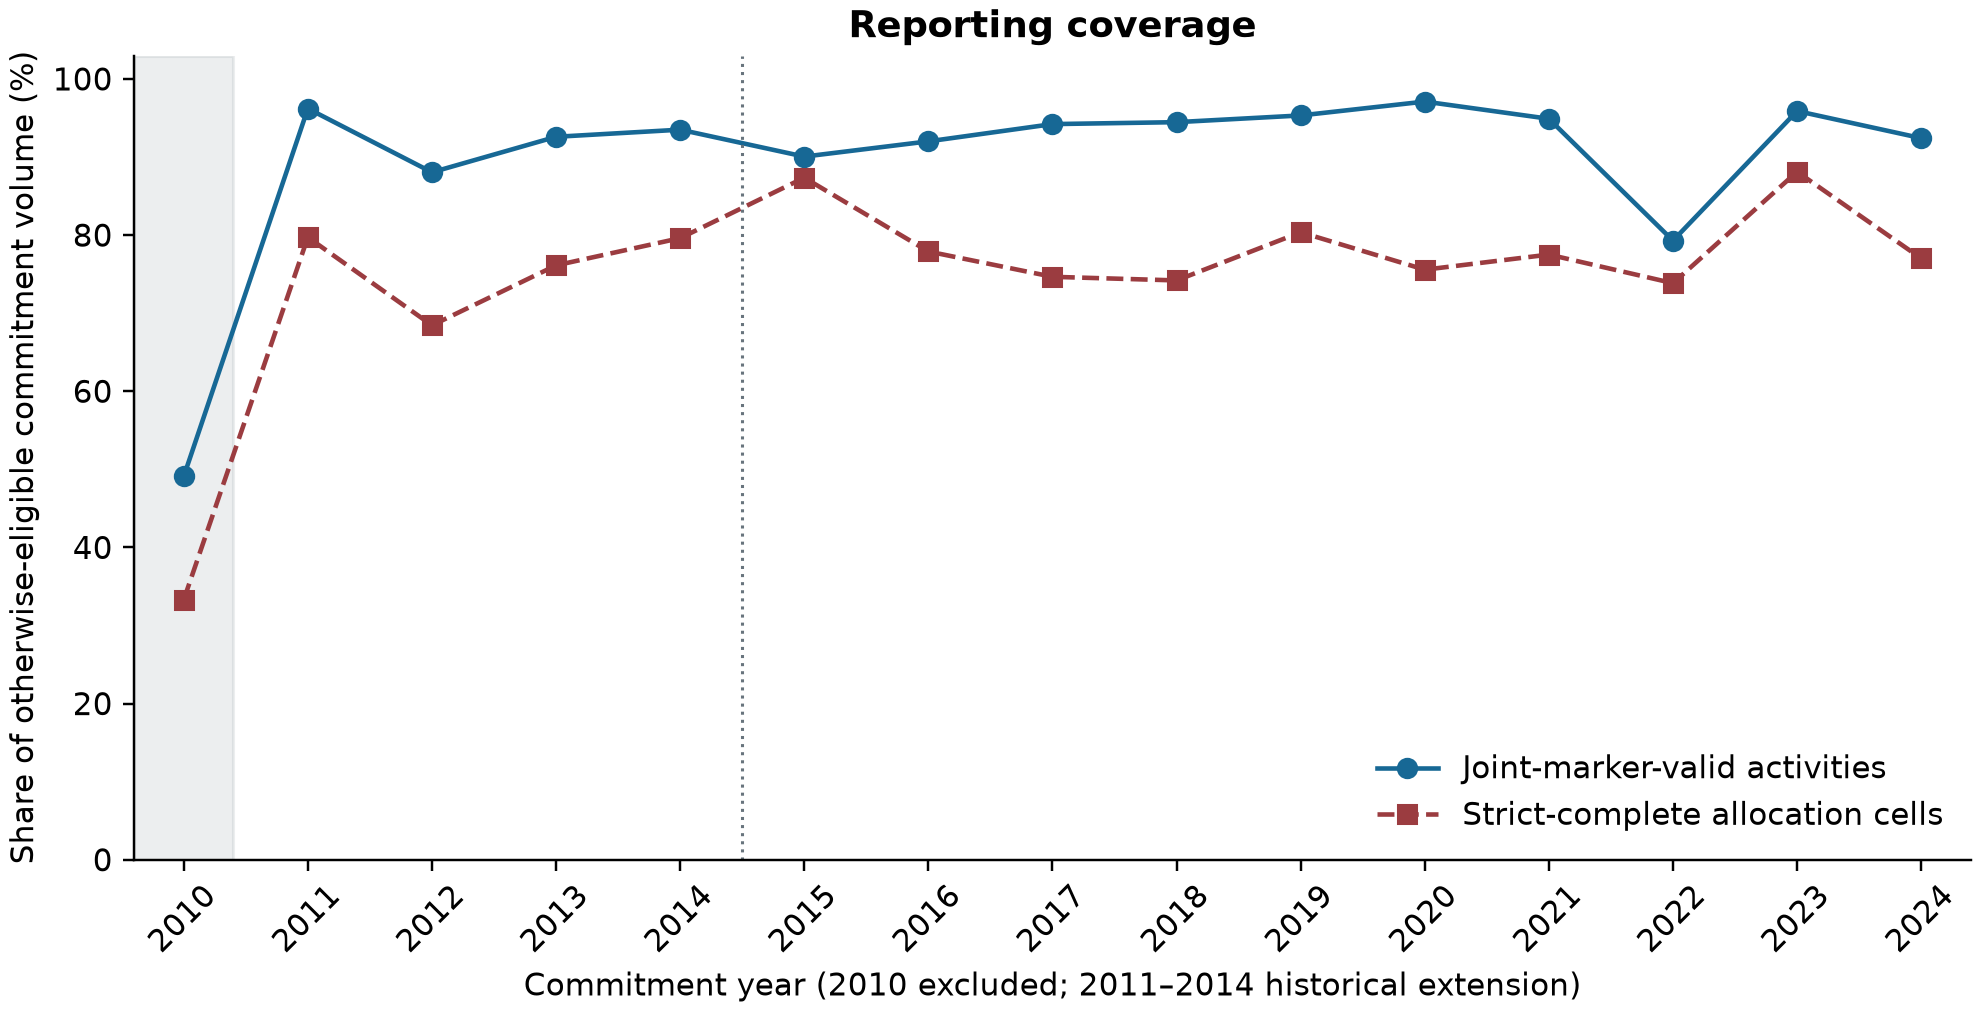

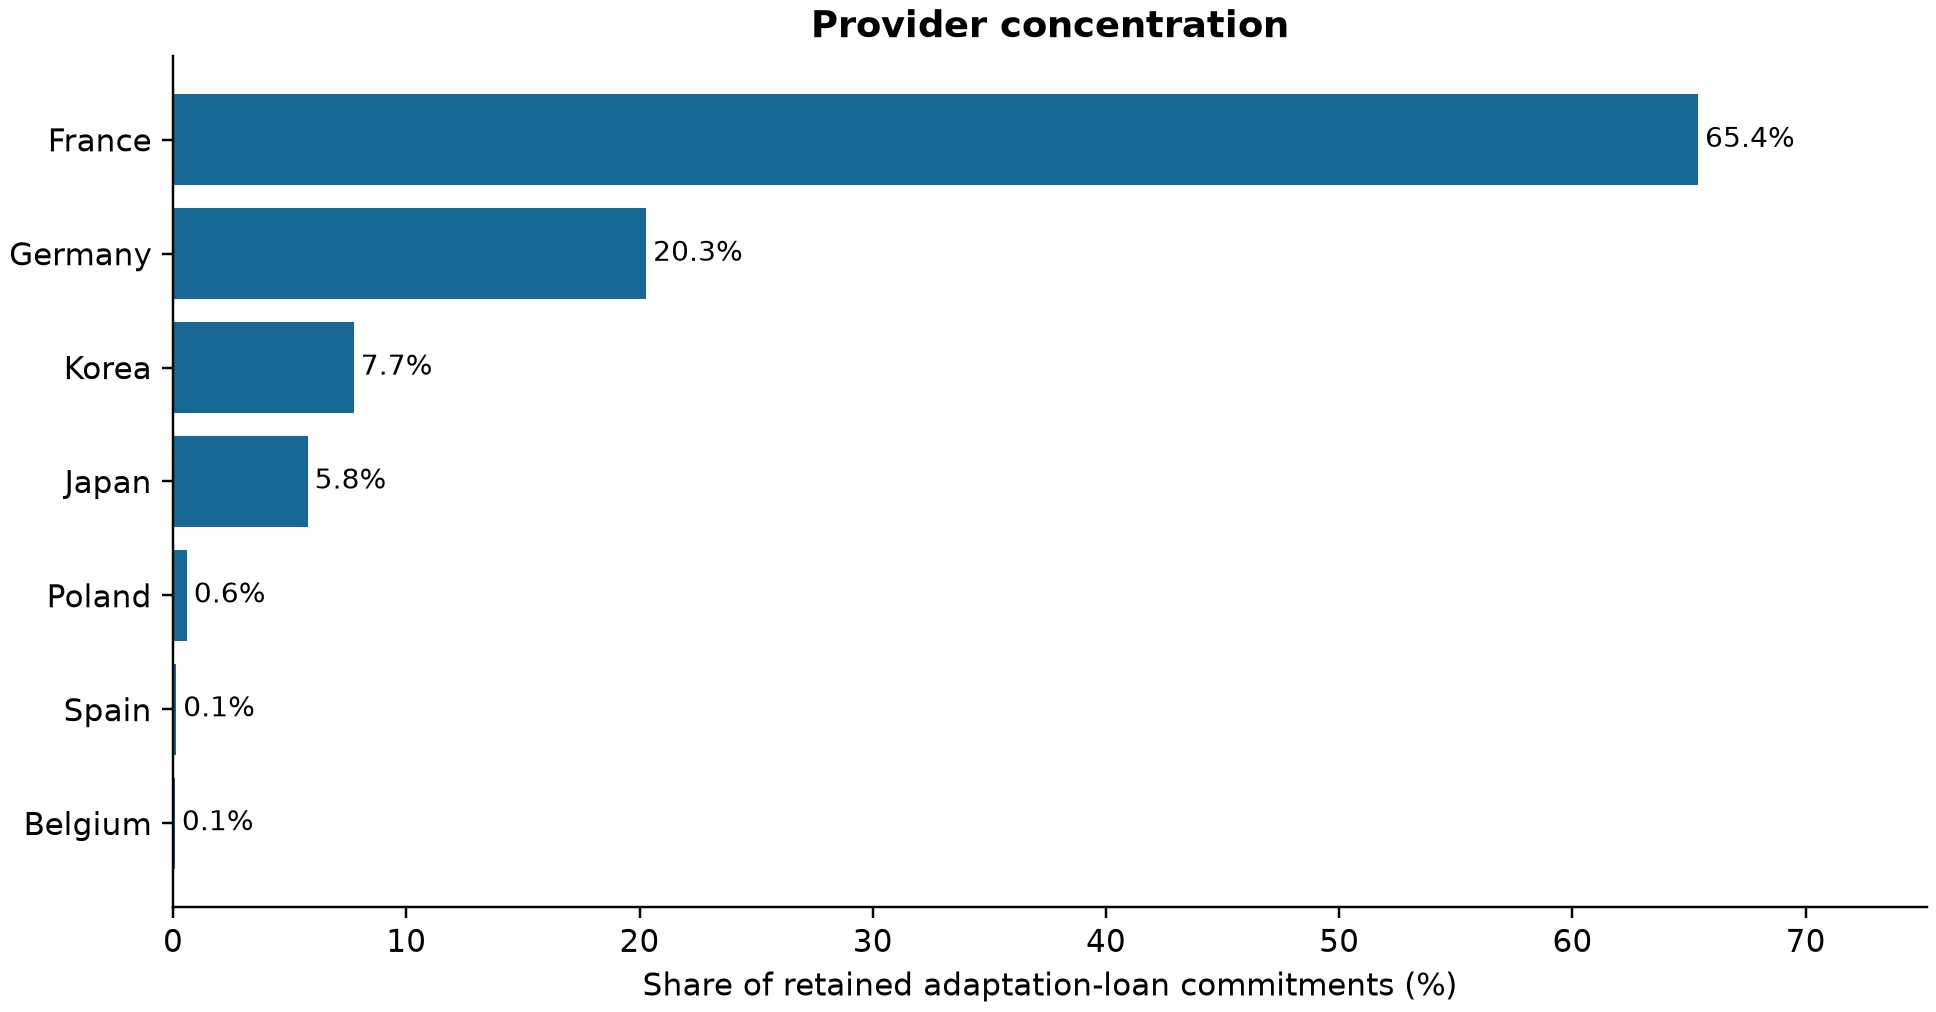

In [8]:
display(Image(filename=str(OUT/'paper/figure2_reporting_coverage.png')))
display(Image(filename=str(OUT/'paper/figure3_loan_provider_concentration.png')))

Exploratory temporal models and post-baseline diagnostics

Annual slope equality and fixed cutoff tests are exploratory, do not identify a policy intervention and have different restrictions. A fixed 2014 income moderator and all-provider omission analysis were added after observing baseline results for explicitly stated theoretical and concentration concerns; their timing is recorded.

In [9]:
for file in ['adaptation_annual_slopes/annual_slope_equality_test.json','exploratory_cutoffs.csv','adaptation_total_provider_influence_postbaseline.csv']:
    path=MODELS/file
    if path.exists():
        print(file)
        if path.suffix=='.json': print(path.read_text())
        else: display(pd.read_csv(path))
    else: print(file,': not yet available')

adaptation_annual_slopes/annual_slope_equality_test.json
{
  "null": "all annual debt-vulnerability interaction slopes equal",
  "chi2": 15.46423413315314,
  "df": 13,
  "pvalue": 0.27927422251599704,
  "interpretation": "exploratory pooled temporal heterogeneity; no policy-break identification"
}
exploratory_cutoffs.csv
adaptation_total_provider_influence_postbaseline.csv


,cutoff,n,estimate,variance,se,z,...,ci95_high,p_t_recipient,ci95_t_low,ci95_t_high,inference_valid,p_holm_cutoff_family
0,2012,71661,-0.2799,0.1229,0.3505,-0.7983,...,0.4072,0.4264,-0.9747,0.4150,True,0.6179
1,2015,71661,0.4849,0.2272,0.4766,1.0174,...,1.4191,0.3112,-0.4598,1.4297,True,0.6179
2,2018,71661,0.4092,0.0521,0.2283,1.7924,...,0.8567,0.0759,-0.0433,0.8617,True,0.2923
3,2019,71661,0.3780,0.0515,0.2270,1.6656,...,0.8229,0.0987,-0.0718,0.8279,True,0.2923
4,2020,71661,0.4632,0.0461,0.2148,2.1563,...,0.8842,0.0333,0.0374,0.8890,True,0.1553


,excluded_provider,provider_name,baseline_volume_share,input_n,retained_n,recipients,...,ci95_low,ci95_high,p_t_recipient,ci95_t_low,ci95_t_high,inference_valid
0,1,Austria,0.0032,67722,52775,108,...,0.2065,0.8582,0.0018,0.2027,0.8619,True
1,2,Belgium,0.0015,68569,53495,108,...,0.2071,0.8562,0.0017,0.2034,0.8599,True
2,3,Denmark,0.0103,68362,53163,108,...,0.2018,0.8594,0.0020,0.1981,0.8631,True
3,4,France,0.4264,66292,51278,108,...,0.1802,0.7056,0.0013,0.1772,0.7086,True
4,5,Germany,0.2319,63726,49201,107,...,0.1213,0.7776,0.0084,0.1175,0.7814,True
5,6,Italy,0.0071,65956,50647,108,...,0.2109,0.8739,0.0018,0.2071,0.8777,True
6,7,Netherlands,0.0165,67653,52790,108,...,0.1677,0.8584,0.0044,0.1638,0.8623,True
7,8,Norway,0.0145,66813,52298,108,...,0.2104,0.8834,0.0019,0.2066,0.8873,True
8,9,Portugal,0.0004,67210,52624,108,...,0.2069,0.8561,0.0018,0.2031,0.8598,True
9,10,Sweden,0.0198,67243,52227,108,...,0.2177,0.8723,0.0015,0.2140,0.8761,True


In [10]:
for name in ['adaptation_income_moderator_postbaseline','adaptation_vulnerability_year_postbaseline']:
    print(name)
    result=pd.read_csv(MODELS/name/'coefficients.csv')
    display(result[result.term.isin(['debt10','interaction','income_debt_interaction'])])

adaptation_income_moderator_postbaseline
adaptation_vulnerability_year_postbaseline


,term,estimate,variance,se,z,p_normal,ci95_low,ci95_high,p_t_recipient,ci95_t_low,ci95_t_high,inference_valid
0,debt10,-0.2642,0.0323,0.1797,-1.4705,0.1414,-0.6164,0.0880,0.1444,-0.6205,0.0920,True
1,interaction,0.5128,0.0236,0.1535,3.3412,0.0008,0.2120,0.8136,0.0011,0.2086,0.8171,True
4,income_debt_interaction,-0.1217,0.0229,0.1513,-0.8043,0.4212,-0.4182,0.1749,0.4230,-0.4216,0.1782,True


,term,estimate,variance,se,z,p_normal,ci95_low,ci95_high,p_t_recipient,ci95_t_low,ci95_t_high,inference_valid
0,debt10,-0.2122,0.0319,0.1785,-1.1885,0.2346,-0.5620,0.1377,0.2373,-0.5660,0.1417,True
1,interaction,0.3936,0.0144,0.1200,3.2814,0.0010,0.1585,0.6288,0.0014,0.1558,0.6315,True


Reproducibility

The actual runtime is a pinned Python virtual environment, not a Conda execution. requirements.lock.txt records installed packages. environment.yml is a Conda recreation specification, not a claim that it was executed.

From the paper root, run the source acquisition scripts if rebuilding raw inputs, then run ppml_pipeline.py prepare, main, secondary and temporal in that order under analysis/.venv/bin/python. Run run_universe_sensitivities.py and run_postbaseline_diagnostics.py for their separately identified diagnostics, and render_results.py to regenerate figures and tables. All input hashes are checked against design_lock.yaml. Independent verification is summarized in VALIDATION.md.

None of these associations identifies donor intent, an optimal financing rule, realised resilience outcomes or causal debt compensation.